# Wine Quality Prediction Using Machine Learning

**Team BDA**

This notebook documents the complete machine learning workflow for predicting the quality score of red wine from physicochemical measurements. It covers dataset understanding, exploratory analysis, preprocessing, model training, evaluation, comparison, feature importance, and model persistence.

## Project objectives

- Predict the numerical `quality` score using 11 laboratory measurements.
- Compare a Decision Tree Regressor with a Random Forest Regressor.
- Evaluate the models using MAE, MSE, and RMSE.
- Save the selected model and supporting artifacts for the Streamlit application.

The task is treated as **regression** because the target is a numerical quality score.

In [1]:
from pathlib import Path
import json
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

ROOT = Path.cwd()
DATA_PATH = ROOT / "data" / "winequality-red.csv"
MODEL_DIR = ROOT / "models"
ARTIFACT_DIR = ROOT / "artifacts"
MODEL_DIR.mkdir(exist_ok=True)
ARTIFACT_DIR.mkdir(exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")

## 1. Load and understand the dataset

The dataset is the red wine portion of the UCI Wine Quality Dataset. It uses semicolons as separators and contains 1,599 observations, 11 input features, and the `quality` target.

In [2]:
data = pd.read_csv(DATA_PATH, sep=";")
print(f"Dataset shape: {data.shape}")
print(f"Missing values: {int(data.isna().sum().sum())}")
print(f"Duplicate rows: {int(data.duplicated().sum())}")
display(data.head())
display(data.describe().T.round(3))

Dataset shape: (1599, 12)
Missing values: 0
Duplicate rows: 240


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.320,1.741,4.600,7.100,7.900,9.200,15.900
volatile acidity,1599.0,0.528,0.179,0.120,0.390,0.520,0.640,1.580
citric acid,1599.0,0.271,0.195,0.000,0.090,0.260,0.420,1.000
residual sugar,1599.0,2.539,1.410,0.900,1.900,2.200,2.600,15.500
chlorides,1599.0,0.087,0.047,0.012,0.070,0.079,0.090,0.611
free sulfur dioxide,1599.0,15.875,10.460,1.000,7.000,14.000,21.000,72.000
total sulfur dioxide,1599.0,46.468,32.895,6.000,22.000,38.000,62.000,289.000
density,1599.0,0.997,0.002,0.990,0.996,0.997,0.998,1.004
pH,1599.0,3.311,0.154,2.740,3.210,3.310,3.400,4.010
sulphates,1599.0,0.658,0.170,0.330,0.550,0.620,0.730,2.000


The input variables describe acidity, sugar, chlorides, sulfur dioxide, density, pH, sulphates, and alcohol. The quality score is the supervised learning target.

In [3]:
feature_names = [column for column in data.columns if column != "quality"]
features = data[feature_names]
target = data["quality"]
print("Input features:")
print(feature_names)
print(f"Observed quality scores: {sorted(target.unique().tolist())}")
print("Quality counts:")
display(target.value_counts().sort_index().rename("count").to_frame())

Input features:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Observed quality scores: [3, 4, 5, 6, 7, 8]
Quality counts:


,count
quality,
3,10
4,53
5,681
6,638
7,199
8,18


## 2. Exploratory data analysis

The first plot shows the distribution of observed quality scores. The second plot shows pairwise Pearson correlations across the numeric columns.

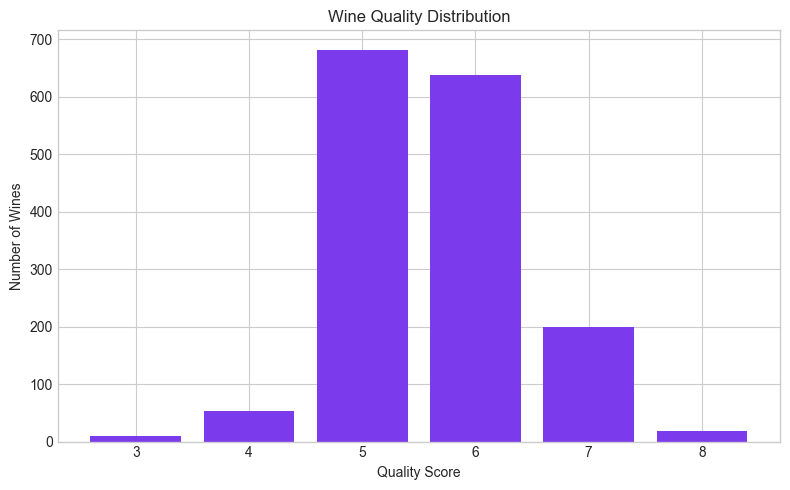

In [4]:
quality_counts = target.value_counts().sort_index()
figure, axis = plt.subplots(figsize=(8, 5))
axis.bar(quality_counts.index.astype(str), quality_counts.values, color="#7c3aed")
axis.set_title("Wine Quality Distribution")
axis.set_xlabel("Quality Score")
axis.set_ylabel("Number of Wines")
figure.tight_layout()
display(figure)
figure.savefig(ARTIFACT_DIR / "quality_distribution.png", dpi=160)
plt.close(figure)

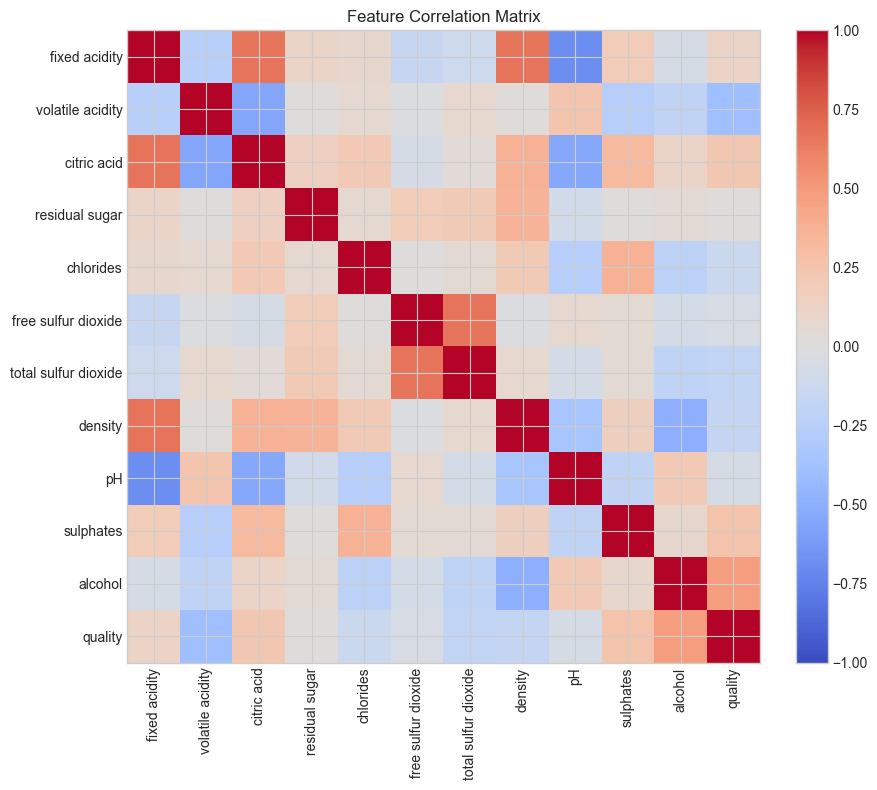

,correlation with quality
alcohol,0.476166
volatile acidity,-0.390558
sulphates,0.251397
citric acid,0.226373
total sulfur dioxide,-0.185100
density,-0.174919
chlorides,-0.128907
fixed acidity,0.124052
pH,-0.057731
free sulfur dioxide,-0.050656


In [5]:
correlation = data.corr(numeric_only=True)
figure, axis = plt.subplots(figsize=(10, 8))
image = axis.imshow(correlation, cmap="coolwarm", vmin=-1, vmax=1)
axis.set_xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
axis.set_yticks(range(len(correlation.columns)), correlation.columns)
axis.set_title("Feature Correlation Matrix")
figure.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
figure.tight_layout()
display(figure)
figure.savefig(ARTIFACT_DIR / "correlation_matrix.png", dpi=160)
plt.close(figure)

quality_correlations = correlation["quality"].drop("quality").sort_values(key=abs, ascending=False)
display(quality_correlations.rename("correlation with quality").to_frame())

## 3. Train-test split and preprocessing

The data is split into 80% training data and 20% testing data. The pipeline uses median imputation and standardization before the estimator. The current dataset has no missing values, but the imputer provides defensive handling for future inputs.

In [6]:
train_features, test_features, train_target, test_target = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

def make_pipeline(model):
    return Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", model),
        ]
    )

print(f"Training rows: {len(train_features)}")
print(f"Testing rows: {len(test_features)}")

Training rows: 1279
Testing rows: 320


## 4. Model development

Two tree-based regression models are compared:

- **Decision Tree Regressor:** one constrained tree that learns sequential feature-based splits.
- **Random Forest Regressor:** an ensemble of 300 trees whose predictions are averaged.

The Random Forest is expected to be more stable because it combines many trees instead of depending on one tree.

In [7]:
model_definitions = {
    "Decision Tree Regressor": DecisionTreeRegressor(
        max_depth=5,
        min_samples_leaf=3,
        random_state=42
    ),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),
}

def calculate_metrics(actual, predicted):
    return {
        "MAE": round(float(mean_absolute_error(actual, predicted)), 6),
        "MSE": round(float(mean_squared_error(actual, predicted)), 6),
        "RMSE": round(float(np.sqrt(mean_squared_error(actual, predicted))), 6),
    }

trained_models = {}
comparison = {}
for name, estimator in model_definitions.items():
    pipeline = make_pipeline(estimator)
    pipeline.fit(train_features, train_target)
    predictions = pipeline.predict(test_features)
    trained_models[name] = pipeline
    comparison[name] = calculate_metrics(test_target, predictions)

metrics_frame = pd.DataFrame(comparison).T
display(metrics_frame)

,MAE,MSE,RMSE
Decision Tree Regressor,0.506914,0.435915,0.660239
Random Forest Regressor,0.429716,0.311323,0.557963


## 5. Model evaluation and selection

### Evaluation metrics: full forms and presentation reference

| Short name | Full form | Meaning | Better value |
|---|---|---|---|
| **MAE** | **Mean Absolute Error** | Average absolute difference between actual and predicted quality, measured in quality points. | Lower |
| **MSE** | **Mean Squared Error** | Average squared prediction error; gives more weight to large mistakes. | Lower |
| **RMSE** | **Root Mean Squared Error** | Square root of MSE; expresses the error back in quality-score units. | Lower |

**Remember:** lower MAE, MSE, and RMSE are better.

The final model is selected using the lowest test RMSE.


In [8]:
best_name = min(comparison, key=lambda name: comparison[name]["RMSE"])
best_model = trained_models[best_name]
print(f"Selected model: {best_name}")
print(f"RMSE improvement over Decision Tree: {(1 - comparison[best_name]['RMSE'] / comparison['Decision Tree Regressor']['RMSE']) * 100:.2f}%")

Selected model: Random Forest Regressor
RMSE improvement over Decision Tree: 15.49%


## 6. Feature importance

For the selected Random Forest, impurity-based feature importance indicates which variables were most useful for the fitted model's split decisions. These values show model behavior and should not be interpreted as proof of causation.

,feature,importance
10,alcohol,0.283944
9,sulphates,0.158892
1,volatile acidity,0.110393
6,total sulfur dioxide,0.077730
4,chlorides,0.067185
8,pH,0.057700
3,residual sugar,0.051890
0,fixed acidity,0.051377
2,citric acid,0.048587
7,density,0.047210


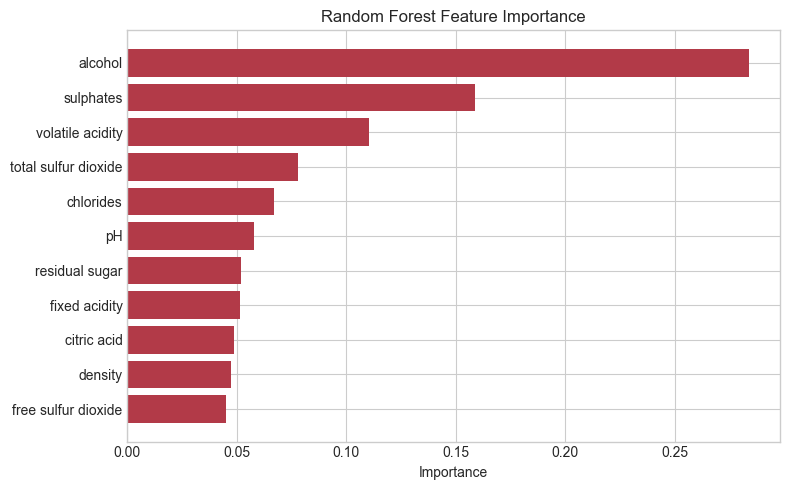

In [9]:
feature_importance = pd.DataFrame(
    {
        "feature": feature_names,
        "importance": best_model.named_steps["model"].feature_importances_,
    }
).sort_values("importance", ascending=False)

display(feature_importance)
feature_importance.to_csv(ARTIFACT_DIR / "feature_importance.csv", index=False)

figure, axis = plt.subplots(figsize=(8, 5))
ordered = feature_importance.sort_values("importance")
axis.barh(ordered["feature"], ordered["importance"], color="#b23a48")
axis.set_title("Random Forest Feature Importance")
axis.set_xlabel("Importance")
figure.tight_layout()
display(figure)
plt.close(figure)

## 7. Actual versus predicted quality

Points close to the diagonal indicate predictions close to the observed quality score.

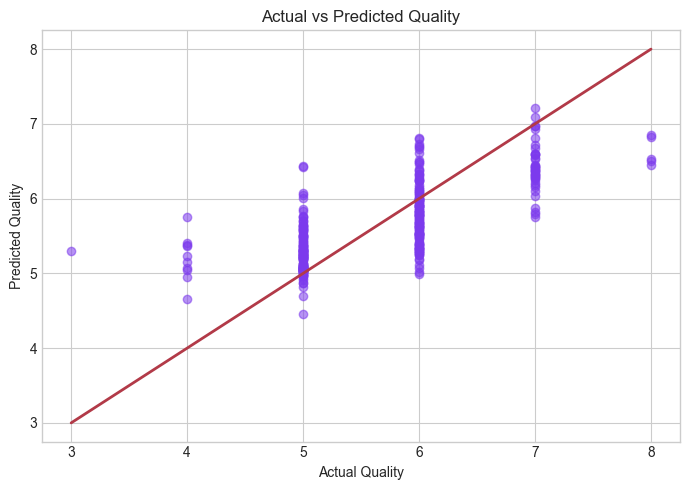

In [10]:
test_output = test_features.copy()
test_output["actual_quality"] = test_target.to_numpy()
test_output["predicted_quality"] = best_model.predict(test_features)

figure, axis = plt.subplots(figsize=(7, 5))
axis.scatter(test_output["actual_quality"], test_output["predicted_quality"], alpha=0.55, color="#7c3aed")
axis.plot([test_target.min(), test_target.max()], [test_target.min(), test_target.max()], color="#b23a48", linewidth=2)
axis.set_title("Actual vs Predicted Quality")
axis.set_xlabel("Actual Quality")
axis.set_ylabel("Predicted Quality")
figure.tight_layout()
display(figure)
figure.savefig(ARTIFACT_DIR / "actual_vs_predicted.png", dpi=160)
plt.close(figure)

test_output.to_csv(ARTIFACT_DIR / "test_predictions.csv", index=False, float_format="%.6f")

## 8. Save the trained pipeline and metadata

The complete preprocessing and model pipeline is saved with Joblib. Saving the pipeline preserves the same transformations for Streamlit inference. Deployment metrics remain generated by train_model.py.

In [11]:
joblib.dump(best_model, MODEL_DIR / "wine_quality_model.joblib")

bounds = {
    feature: {
        "min": float(features[feature].min()),
        "max": float(features[feature].max()),
        "median": float(features[feature].median()),
    }
    for feature in feature_names
}
metadata = {
    "target": "quality",
    "features": feature_names,
    "best_model": best_name,
    "dataset": "UCI Machine Learning Repository Wine Quality Dataset - Red Wine",
    "bounds": bounds,
}
(MODEL_DIR / "metadata.json").write_text(json.dumps(metadata, indent=2))
print("Saved model and artifacts successfully.")

Saved model and artifacts successfully.


## 9. Conclusion

The Random Forest Regressor was selected because it achieved the lowest error values and lowest RMSE on the held-out test split. The saved pipeline is used by the Streamlit application to accept 11 wine measurements and return an educational quality estimate.

The result should be interpreted carefully because wine quality ratings are subjective, the target distribution is uneven, and the current evaluation uses one split containing duplicate rows in the dataset.